# 

Apex Project: Team Plotmasters

1.  Utkarsh Tripathi (2025EM1100146)
2.  Juwaria Qadri (2025EM1100132)
3.  Mohammed Omar (2025EM1100235)
4.  Merin Ann Cherian (2025EM1100211)

The notebook is divided into the following components

-   Data Loading
-   Data Cleaning
-   EDA
-   Feature Engineering
-   Summary

In [31]:
# Library imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
# Dataset loading

# df=pd.read_csv('/content/blinkit_orders.csv')
df = pd.read_csv('../resources/data/blinkit_orders.csv')


In [33]:

def data_validation(df):

    print("Shape of DataFrame:")
    print(df.shape)

    # Display head rows
    print("Top 5 Rows:")
    display(df.head())

    # Basic info about the data
    print("Basic Information:")
    print(df.info())

    # Count null values and describe statistics
    print("Count of Null Values:")
    display(df.isnull().sum())

    # print("Descriptive Statistics:")
    # display(df.describe())

    print("Number of Duplicated Rows:", df.duplicated().sum())

data_validation(df)


Shape of DataFrame:
(5000, 10)
Top 5 Rows:

Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   object 
 3   promised_delivery_time  5000 non-null   object 
 4   actual_delivery_time    5000 non-null   object 
 5   delivery_status         5000 non-null   object 
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   object 
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 390.8+ KB
None
Count of Null Values:

order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
dtype: int64

Number of Duplicated Rows: 0

In [34]:
# Checking for anomalies
df.describe(include='all')

In [35]:
# Categorical Column Summary
df.describe(include=['object'])

In [36]:
if 'order_total' in df.columns:
    invalid_order_total = df[df['order_total'] <= 0]
    print("Rows with Invalid (≤0) Order Total:\n", invalid_order_total)

Rows with Invalid (≤0) Order Total:
 Empty DataFrame
Columns: [order_id, customer_id, order_date, promised_delivery_time, actual_delivery_time, delivery_status, order_total, payment_method, delivery_partner_id, store_id]
Index: []

In [37]:
# inconsistent date. need to be rectified before proceeding. need to be in the same format in all columns.
# invalid rows can be removed
if {'promised_delivery_time', 'actual_delivery_time'}.issubset(df.columns):
    df['promised_delivery_time'] = pd.to_datetime(df['promised_delivery_time'], errors='coerce')
    df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'], errors='coerce')
    invalid_delivery = df[df['actual_delivery_time'] < df['order_date']]
    print("Rows with Invalid Delivery Times (Before Order Date):", invalid_delivery, sep="\n")


Rows with Invalid Delivery Times (Before Order Date):
Empty DataFrame
Columns: [order_id, customer_id, order_date, promised_delivery_time, actual_delivery_time, delivery_status, order_total, payment_method, delivery_partner_id, store_id]
Index: []

In [38]:
#unique countsin each column
print("Unique Value Counts per Column:", df.nunique(), sep="\n")

Unique Value Counts per Column:
order_id                  5000
customer_id               2172
order_date                5000
promised_delivery_time    4999
actual_delivery_time      5000
delivery_status              3
order_total               4550
payment_method               4
delivery_partner_id       5000
store_id                  5000
dtype: int64

In [39]:
df

5000 rows × 10 columns

## Data Cleaning

In [40]:
# Load dataset
# df = pd.read_csv("blinkit_orders.csv")

# Drop irrelevant columns (none in this dataset)
irrelevant_cols = ['Cust_Name']
df.drop(columns=[col for col in irrelevant_cols if col in df.columns], inplace=True)

# Drop columns with too many missing values
threshold = 0.5
df = df.loc[:, df.isnull().mean() < threshold]

# Impute missing values (not needed here)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        elif df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(method='ffill', inplace=True)

# Remove duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {before - df.shape[0]} duplicate rows")

#  Handle outliers in 'order_total' using IQR capping
Q1 = df['order_total'].quantile(0.25)
Q3 = df['order_total'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['order_total'] = np.where(df['order_total'] < lower, lower, df['order_total'])
df['order_total'] = np.where(df['order_total'] > upper, upper, df['order_total'])

# Convert date/time columns to datetime
for col in ['order_date', 'promised_delivery_time', 'actual_delivery_time']:
    df[col] = pd.to_datetime(df[col], dayfirst=False, errors='coerce')

# Calculate delivery delay (in minutes)
df['delivery_delay_minutes'] = (df['actual_delivery_time'] - df['promised_delivery_time']).dt.total_seconds() / 60


# Convert categorical-like columns
df['payment_method'] = df['payment_method'].astype('category')
df['delivery_status'] = df['delivery_status'].astype('category')

# Save cleaned dataset
df_cleaned = df.copy()
df.to_csv("blinkit_orders_cleaned.csv", index=False)

print("Data cleaning completed successfully!")
print("Final Data Shape:", df_cleaned.shape)
print("Data Types:\n", df_cleaned.dtypes)

Removed 0 duplicate rows
Data cleaning completed successfully!
Final Data Shape: (5000, 11)
Data Types:
 order_id                           int64
customer_id                        int64
order_date                datetime64[ns]
promised_delivery_time    datetime64[ns]
actual_delivery_time      datetime64[ns]
delivery_status                 category
order_total                      float64
payment_method                  category
delivery_partner_id                int64
store_id                           int64
delivery_delay_minutes           float64
dtype: object

In [41]:
df_cleaned

5000 rows × 11 columns

# Exploratory Data Analysis

### Summary Statistics

In [42]:
print("Numerical Columns")

# Descriptive stats
print("Descriptive stats", df_cleaned[['order_total', 'delivery_delay_minutes']].describe(), sep="\n")

# Quantiles
print("Distribution of Spending \n", df_cleaned[['order_total']].quantile([0.25, 0.5, 0.75, 0.95]), sep="\n")

# Correlation
print("Correlation between order total and delivery delay in minutes \n", df_cleaned[['order_total', 'delivery_delay_minutes']].corr(), sep="\n")

print("\n\n Categorical Columns")

# distribution overview of payment methods
print("Payment Methods Distribution", df_cleaned['payment_method'].value_counts(), sep="\n")

# distribution overview of delivery outcomes
print("Delivery Status Distribution", df_cleaned['delivery_status'].value_counts(normalize=True), sep="\n")

Numerical Columns
Descriptive stats
       order_total  delivery_delay_minutes
count  5000.000000             5000.000000
mean   2201.674720                4.443000
std    1302.416242                8.063929
min      13.250000               -5.000000
25%    1086.215000               -1.000000
50%    2100.690000                2.000000
75%    3156.882500                8.000000
max    6262.883750               30.000000
Distribution of Spending 

      order_total
0.25    1086.2150
0.50    2100.6900
0.75    3156.8825
0.95    4452.7910
Correlation between order total and delivery delay in minutes 

                        order_total  delivery_delay_minutes
order_total                1.000000               -0.002591
delivery_delay_minutes    -0.002591                1.000000


 Categorical Columns
Payment Methods Distribution
payment_method
Card      1285
Cash      1257
Wallet    1244
UPI       1214
Name: count, dtype: int64
Delivery Status Distribution
delivery_status
On Time           

In [43]:
# Filter orders for significantly delayed
significantly_delayed_orders = df_cleaned[df_cleaned['delivery_status'] == 'Significantly Delayed']
print("Significantly delayed orders:\n", significantly_delayed_orders.head())

# Get the count
count_delayed = significantly_delayed_orders.shape[0]
print("Total significantly delayed orders:", count_delayed)

Significantly delayed orders:
       order_id  customer_id          order_date promised_delivery_time  \
23  6905293278     97259564 2024-06-16 10:23:23    2024-06-16 10:36:23   
31  9073572548     97111069 2023-05-02 23:13:42    2023-05-02 23:25:42   
62  2149289255     57579640 2024-11-01 15:00:29    2024-11-01 15:20:29   
70  2122832513     55028958 2024-02-17 19:48:14    2024-02-17 19:58:14   
76  5127172657     32293017 2024-06-11 18:11:31    2024-06-11 18:30:31   

   actual_delivery_time        delivery_status  order_total payment_method  \
23  2024-06-16 11:02:23  Significantly Delayed      1404.68           Cash   
31  2023-05-02 23:47:42  Significantly Delayed      1091.89           Card   
62  2024-11-01 15:39:29  Significantly Delayed      2687.31           Cash   
70  2024-02-17 20:18:14  Significantly Delayed      2037.94            UPI   
76  2024-06-11 18:50:31  Significantly Delayed      2185.50           Cash   

    delivery_partner_id  store_id  delivery_delay_minut

In [44]:
# summary table for each customer showing their total spending, number of orders, and average delivery delay.

customer_summary = df_cleaned.groupby('customer_id').agg({
    'order_total':'sum',
    'order_id':'count',
    'delivery_delay_minutes':'mean'
}).rename(columns={'order_total':'total_spent', 'order_id':'order_count', 'delivery_delay_minutes':'avg_delivery_delay'}).sort_index(level='order_count', ascending=False)

print(customer_summary.head(10))

             total_spent  order_count  avg_delivery_delay
customer_id                                              
99893898         8817.53            4           14.250000
99824171         4515.68            2            9.500000
99784559         2527.14            1           -1.000000
99772709         5208.45            3            7.333333
99734256         8571.89            3            1.333333
99729547         6406.26            3            0.333333
99714944         3576.86            3            2.666667
99707100         9713.18            3            0.333333
99695529        12764.73            3            5.333333
99627097         1856.69            2           -2.500000

In [45]:
# payment method summary

payment_summary_df = df_cleaned.groupby('payment_method', observed=True).agg({
    'order_total':'mean',
    'order_id':'count'
}).rename(columns={
    'order_total':'avg_order_value',
    'order_id':'num_orders'
})

print(payment_summary_df)

                avg_order_value  num_orders
payment_method                             
Card                2229.496449        1285
Cash                2204.028632        1257
UPI                 2189.458323        1214
Wallet              2182.479317        1244

In [46]:
# Store-wise Order Total by Delivery Status

pd.pivot_table(df_cleaned,
               index='store_id',
               columns='delivery_status',
               values='order_total',
               aggfunc='sum',
               fill_value=0,
               observed=False)


5000 rows × 3 columns

In [47]:
# Daily Sales Patterns

daily_sales_df = df.set_index('order_date').resample('D').agg({
    'order_total':'sum',
    'order_id':'count'
}).rename(columns={
    'order_total':'total_sales',
    'order_id':'num_orders'
}).sort_index(level=1, ascending=False)

print(daily_sales_df.head(10))

            total_sales  num_orders
order_date                         
2024-11-04     13820.12           4
2024-11-03     28761.95          12
2024-11-02     10794.55           5
2024-11-01     14781.03           9
2024-10-31     25689.95           8
2024-10-30     23835.14          13
2024-10-29     11223.88           7
2024-10-28     17221.29           8
2024-10-27     11797.07           5
2024-10-26     23652.49          11

### Visualizations

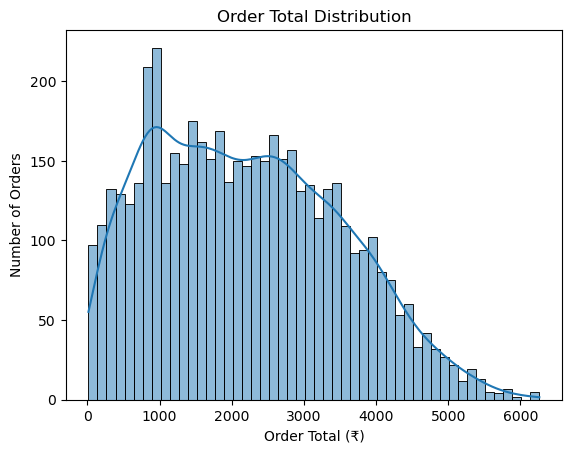

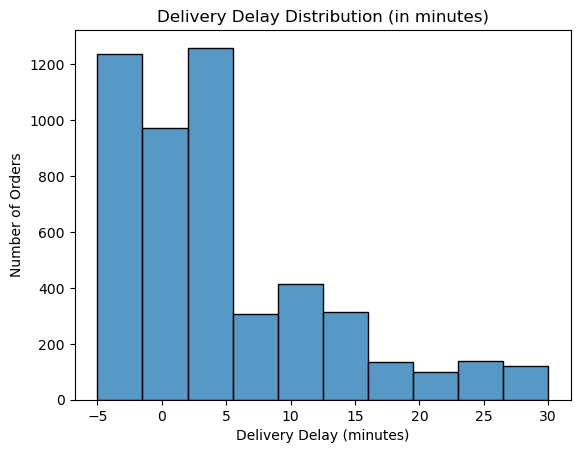

float64
0   -5.0
1    2.0
2    4.0
3   -1.0
4    1.0
Name: delivery_delay_minutes, dtype: float64
count    5000.000000
mean        4.443000
std         8.063929
min        -5.000000
25%        -1.000000
50%         2.000000
75%         8.000000
max        30.000000
Name: delivery_delay_minutes, dtype: float64

In [48]:
# Univariate Analysis

# Numeric Features
# Histogram & KDE
sns.histplot(df['order_total'], kde=True, bins=50)
plt.title('Order Total Distribution')
plt.xlabel('Order Total (₹)')
plt.ylabel('Number of Orders')
plt.show()

sns.histplot(df['delivery_delay_minutes'], bins=10)
plt.title('Delivery Delay Distribution (in minutes)')
plt.xlabel('Delivery Delay (minutes)')
plt.ylabel('Number of Orders')
plt.show()

print(df['delivery_delay_minutes'].dtype)
print(df['delivery_delay_minutes'].head())
print(df['delivery_delay_minutes'].describe())

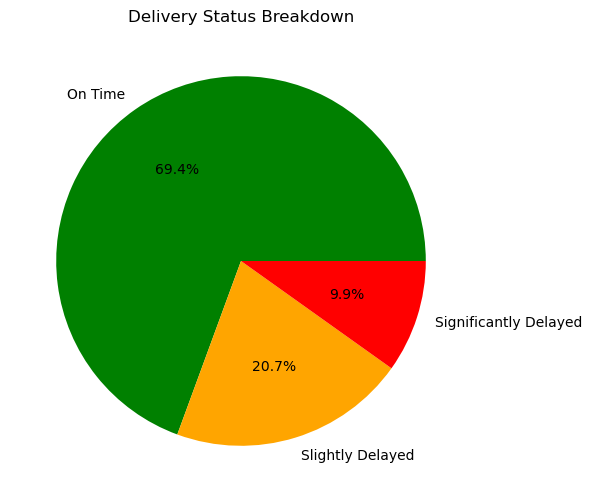

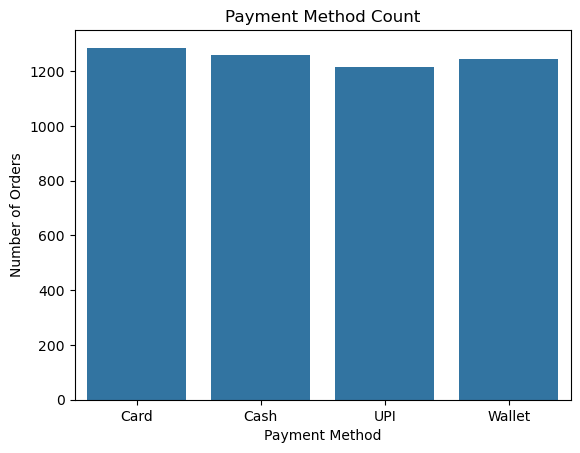

total_orders
1    680
2    686
3    451
4    234
5     82
6     28
7      8
8      2
9      1
Name: count, dtype: int64

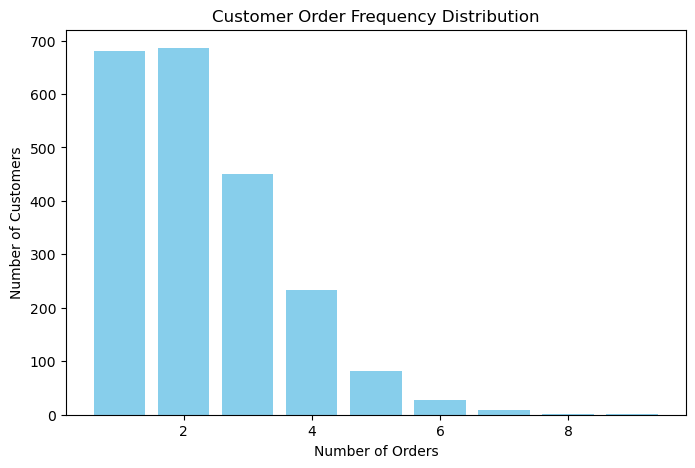

One-time customers: 680
Repeat customers: 1492

In [49]:
# Categorical Features:

# Delivery status breakdown
delivery_counts = df['delivery_status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(delivery_counts, labels=delivery_counts.index, autopct='%1.1f%%', colors=['green','orange','red'])
plt.title("Delivery Status Breakdown")
plt.show()

# Payment method breakdown
sns.countplot(x='payment_method', data=df)
plt.title('Payment Method Count')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.show()

# Customer frequency distribution
customer_metrics = df.groupby('customer_id').agg(
    total_orders=('order_id', 'count'),        # Total orders
    total_spent=('order_total', 'sum'),        # Lifetime value
    avg_order_value=('order_total', 'mean')    # Average order value
)
order_frequency_dist = customer_metrics['total_orders'].value_counts().sort_index()
print(order_frequency_dist)

plt.figure(figsize=(8,5))
plt.bar(order_frequency_dist.index, order_frequency_dist.values, color='skyblue')
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.title("Customer Order Frequency Distribution")
plt.show()

customer_order_counts = df.groupby('customer_id').size()
print(f"One-time customers: {customer_order_counts[customer_order_counts == 1].count()}")
print(f"Repeat customers: {customer_order_counts[customer_order_counts > 1].count()}")

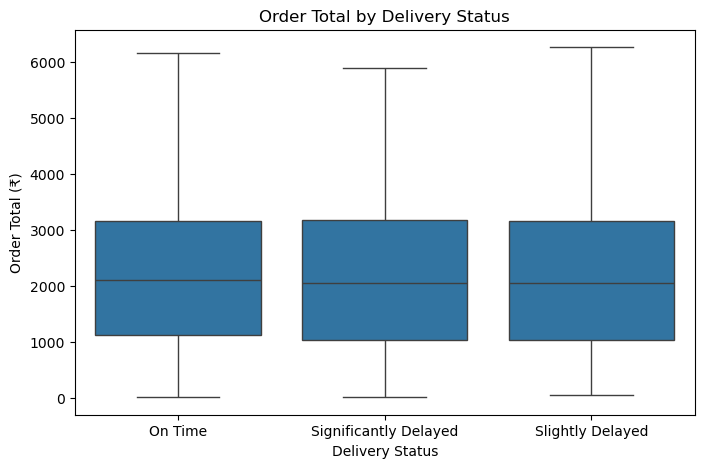

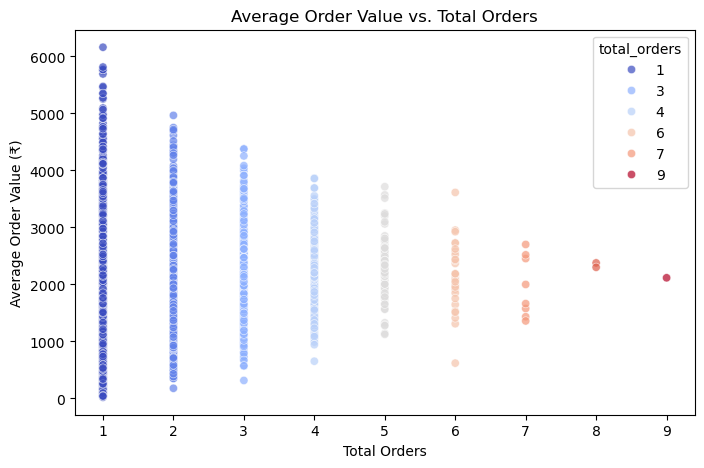

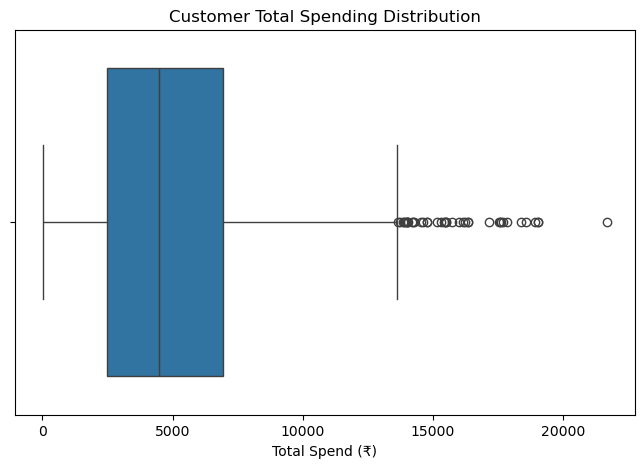

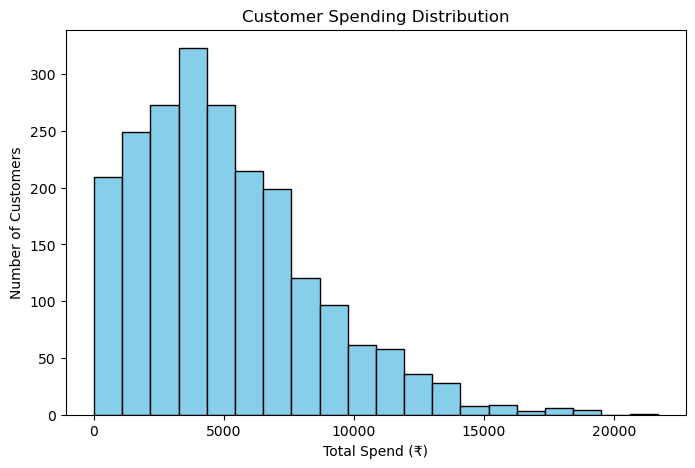

In [50]:
# Bivariate Analysis

# Compare order amounts for On Time vs. Delayed deliveries.
plt.figure(figsize=(8,5))
sns.boxplot(x='delivery_status', y='order_total', data=df)
plt.title("Order Total by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Order Total (₹)")
plt.show()

# Customer Spending Patterns: Average Order Value vs. Total Orders
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=customer_metrics,
    x='total_orders',
    y='avg_order_value',
    hue='total_orders',
    palette='coolwarm',
    alpha=0.7
)
plt.title("Average Order Value vs. Total Orders")
plt.xlabel("Total Orders")
plt.ylabel("Average Order Value (₹)")
plt.show()

# Aggregate total spend per customer
customer_spending = df.groupby('customer_id')['order_total'].sum()

plt.figure(figsize=(8,5))
sns.boxplot(x=customer_spending)
plt.title("Customer Total Spending Distribution")
plt.xlabel("Total Spend (₹)")
plt.show()


plt.figure(figsize=(8,5))
plt.hist(customer_spending, bins=20, color='skyblue', edgecolor='black')
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spend (₹)")
plt.ylabel("Number of Customers")
plt.show()

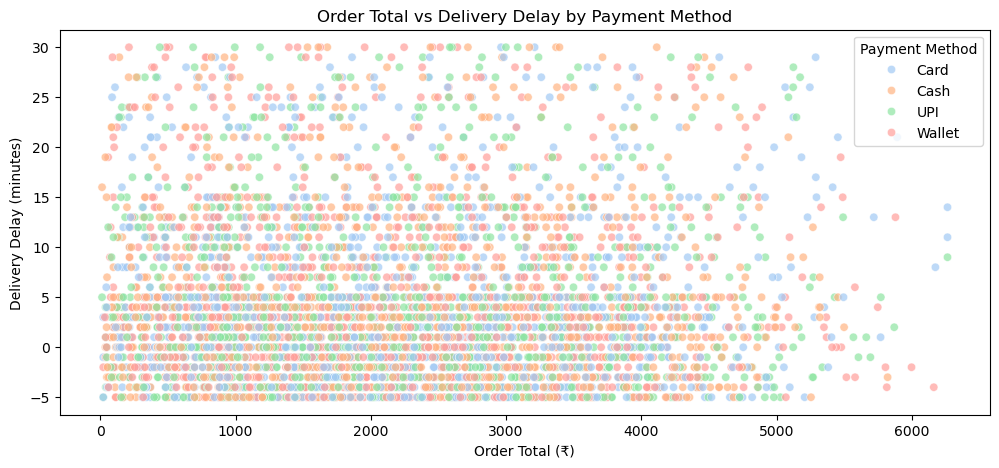

In [51]:
# Multivariate analysis
# Relationship Between Order Total and Delivery Delay

# Scatter plot
plt.figure(figsize=(12,5))
sns.scatterplot(
    x='order_total',
    y='delivery_delay_minutes',
    hue='payment_method',
    data=df,
    alpha=0.7,
    palette='pastel'
)
plt.title("Order Total vs Delivery Delay by Payment Method")
plt.xlabel("Order Total (₹)")
plt.ylabel("Delivery Delay (minutes)")
plt.legend(title="Payment Method")
plt.show()

# Feature Engineering

### TODOs

-   Do we drop the datetime dtype columns in favor of simplified derived
    data point
-   minmax vs Z-score scaling? Not applicable as most datatype are
    categorical in nature.
-   Investigate the high correlation (corr \>= 0.7)
-   For dimensionality reduction, what columns can we drop.

In [52]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split

In [53]:

categorical_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:", list(categorical_cols))

# Label Encoding (for ordinal or simple categorical)
label_enc = LabelEncoder()
for col in categorical_cols:
    if df_cleaned[col].nunique() <= 10:
        df_cleaned[col + '_label'] = label_enc.fit_transform(df_cleaned[col].astype(str))

# One-Hot Encoding (for nominal variables)
df_fe = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# Removing datetime dtypes from analysis cols
df_fe = df_fe.select_dtypes(exclude=['datetime64'])


df_fe.head()

Categorical Columns: ['delivery_status', 'payment_method']

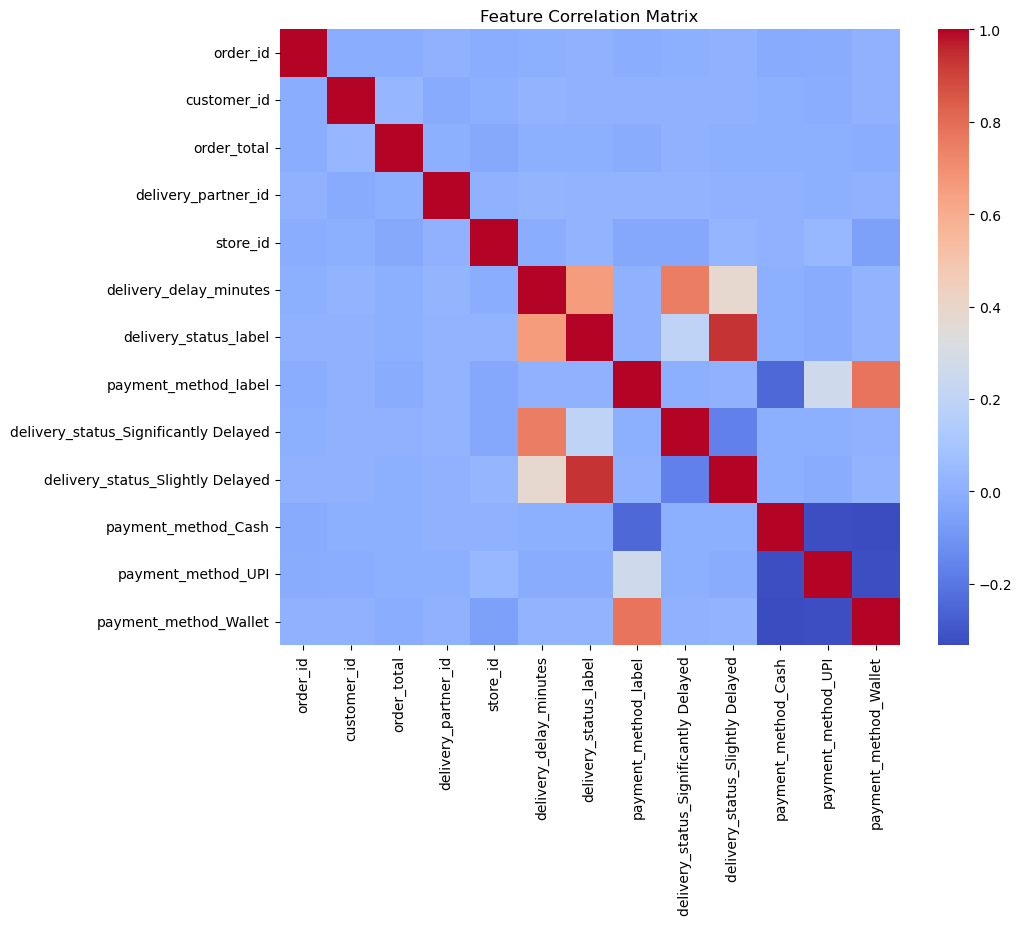

In [54]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_fe.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

In [55]:
corr_matrix = df_fe.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
print("Highly correlated features to drop:", to_drop)
df_fe.drop(columns=to_drop, inplace=True, errors='ignore')

Highly correlated features to drop: ['delivery_status_Slightly Delayed']

In [56]:
df_fe.head()

In [57]:
df_fe.to_csv('df_fe')

# Cluster Modelling

We need to identify a good target label for

Training Test Split

In [58]:
# from sklearn.model_selection import train_test_split

# # X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

# X_train, X_test = train_test_split(df_fe, test_size=0.1)
# print("Train data shape:", X_train.shape)
# print("Test data shape:", X_test.shape)

In [59]:
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler, LabelEncoder


# # Separate the categorical and numerical columns
# cat_cols = df_fe.select_dtypes(include=['object']).columns
# num_cols = df_fe.select_dtypes(include=['int64', 'float64']).columns

# # # Encode the categorical columns
# # le = LabelEncoder()
# # for col in cat_cols:
# #     df_fe[col] = le.fit_transform(df_fe[col])

# # # Standardize the numerical columns
# # scaler = StandardScaler()
# # num_data = df_fe[num_cols]
# # num_scaled = scaler.fit_transform(num_data)
# # df_fe[num_cols] = num_scaled

# # Apply KMeans clustering to the scaled data
# kmeans = KMeans(n_clusters=3)
# kmeans.fit(X_train)
# X_cluster = kmeans.predict(X_test)

# display(X_cluster)

In [60]:
# X_train

In [61]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Select numeric features only (ignore object/datetime)
numeric_cols = df_fe.select_dtypes(include=['int64','float64']).columns
X = df_fe[numeric_cols].copy()

# 2. Scale features for KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit KMeans (choose k = 3 based on your original notebook)
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20,
    max_iter=300
)
kmeans.fit(X_scaled)

# 4. Add cluster labels back to the cleaned dataframe
df_fe["cluster"] = kmeans.labels_

# 5. Evaluate clustering quality
silhouette = silhouette_score(X_scaled, kmeans.labels_)
print(f"Silhouette Score: {silhouette:.4f}")

# 6. Show first few rows with clusters
df_fe.head()


Silhouette Score: 0.1363